# Chargement des données

a la base, fichier train test. Creation de mon propre ensemble a partir du train ( split du train en train test). On n'utilise plus le test²

In [34]:
# Cellules pour détecter et charger un fichier CSV, inspecter les colonnes et faire un pré-traitement minimal.

import os
import glob
import pandas as pd
import tensorflow as tf
from IPython.display import display

In [35]:
base = r"c:\Users\yohan\OneDrive\Bureau\MY NBAI\02_NLP_Toxic_Comment_Detection"
path = r"data\train.csv"
# Lecture robuste (saute les lignes problématiques)
df = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
display(df.head(10))

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [36]:
print("Data set:", df.shape)
print("Colonnes :", df.columns.tolist())
print("\nTypes :")
print(df.dtypes)
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())

Data set: (159571, 8)
Colonnes : ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Types :
id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

Valeurs manquantes par colonne :
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [37]:
labels_columns = df.columns.tolist()[2:]
print("\nColonnes de labels :", labels_columns)


Colonnes de labels : ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [38]:
label_counts = df[labels_columns].sum()
print("\nNombre de commentaires par label :\n",label_counts)


Nombre de commentaires par label :
 toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


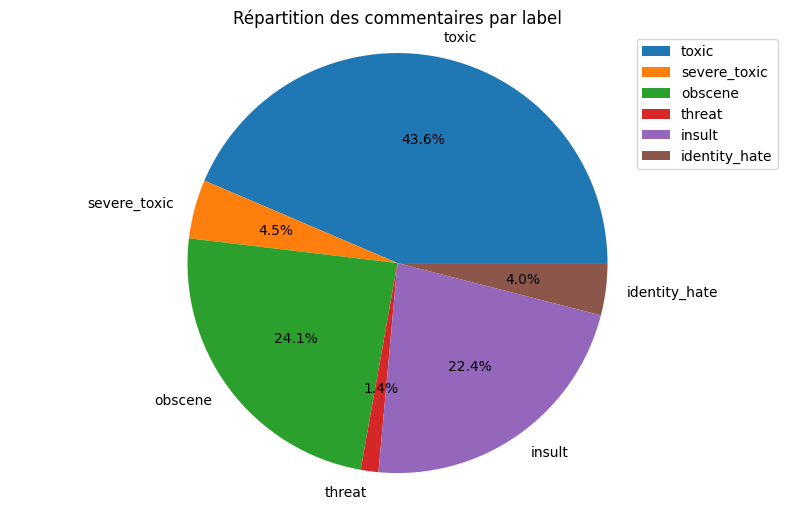

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.pie(label_counts.values, labels=labels_columns, autopct='%1.1f%%')
plt.title('Répartition des commentaires par label')
plt.axis('equal')  # Set the aspect ratio equal so that the pie is a circle
plt.legend(labels_columns, loc='upper right')  # Add a legend to the chart

plt.show()


In [40]:
# Certains labels sont trop peu représentés, on peut envisager de les regrouper
# par exemple en un seul label "toxic" + "severe_toxic".
# de meme avec "threat", "insult"

In [41]:
# Créez une nouvelle colonne "toxic" qui regroupe les labels "toxic" et "severe_toxic"
df['toxic_severe'] = df[['toxic', 'severe_toxic']].max(axis=1)
df['threat_insult'] = df[['threat', 'insult']].max(axis=1)
df['identity_hate_obscene'] = df[['obscene', 'identity_hate']].max(axis=1)

# Supprimez les colonnes "toxic" et "severe_toxic"
df = df.drop(['toxic', 'severe_toxic'], axis=1)
df = df.drop(['threat', 'insult'], axis=1)
df = df.drop(['identity_hate', 'obscene'], axis=1)

In [42]:
display(df.tail(10))

,id,comment_text,toxic_severe,threat_insult,identity_hate_obscene
159561,ffd2e85b07b3c7e4,"""\nNo he did not, read it again (I would have ...",0,0,0
159562,ffd72e9766c09c97,"""\n Auto guides and the motoring press are not...",0,0,0
159563,ffe029a7c79dc7fe,"""\nplease identify what part of BLP applies be...",0,0,0
159564,ffe897e7f7182c90,Catalan independentism is the social movement ...,0,0,0
159565,ffe8b9316245be30,The numbers in parentheses are the additional ...,0,0,0
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0


In [43]:
labels_columns = df.columns.tolist()[2:]
label_counts = df[labels_columns].sum()
print("\nNouveaux nombres de commentaires par label :\n",label_counts)


Nouveaux nombres de commentaires par label :
 toxic_severe             15294
threat_insult             8048
identity_hate_obscene     8822
dtype: int64


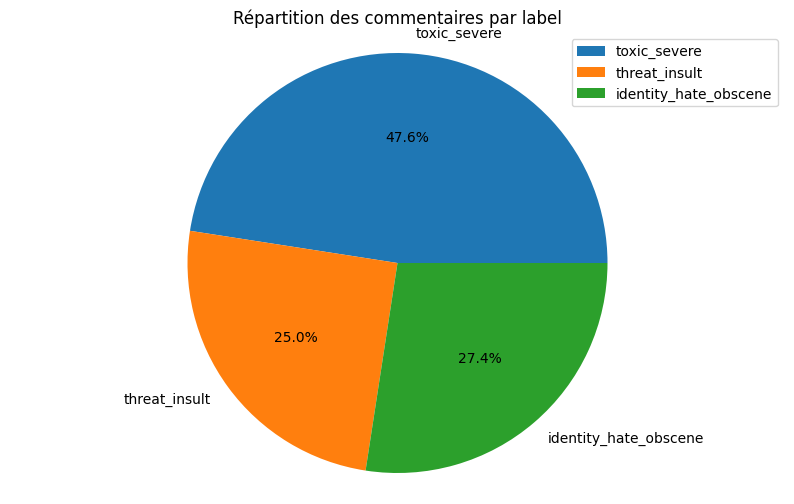

In [44]:
plt.figure(figsize=(10,6))
plt.pie(label_counts.values, labels=labels_columns, autopct='%1.1f%%')
plt.title('Répartition des commentaires par label')
plt.axis('equal')  # Set the aspect ratio equal so that the pie is a circle
plt.legend(labels_columns, loc='upper right')  # Add a legend to the chart

plt.show()

In [45]:
df.iloc[6]['comment_text']

'COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK'

In [46]:
df[df.columns[2:]].iloc[6]

toxic_severe             1
threat_insult            1
identity_hate_obscene    1
Name: 6, dtype: int64

# Preprocessing
    - Standardize each example (usually lowercasing + punctuation stripping)
    - Split each example into substrings (usually words)
    - Recombine substrings into tokens (usually ngrams)
    - Index tokens (associate a unique int value with each token)
    - Transform each example using this index, either into a vector of ints or a dense float vector

In [47]:
from keras.layers import TextVectorization

In [48]:
X = df['comment_text']
X

0         Explanation\nWhy the edits made under my usern...
1         D'aww! He matches this background colour I'm s...
2         Hey man, I'm really not trying to edit war. It...
3         "\nMore\nI can't make any real suggestions on ...
4         You, sir, are my hero. Any chance you remember...
                                ...                        
159566    ":::::And for the second time of asking, when ...
159567    You should be ashamed of yourself \n\nThat is ...
159568    Spitzer \n\nUmm, theres no actual article for ...
159569    And it looks like it was actually you who put ...
159570    "\nAnd ... I really don't think you understand...
Name: comment_text, Length: 159571, dtype: object

In [49]:
y= df[df.columns[2:]].values
y 

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       ...,
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], shape=(159571, 3))

In [50]:
MAX_WORDS = 200000 # nombre max de mots à prendre en compte

In [63]:
# Avant Tokenization, on va faire la lemmatisation avevc spacy
import spacy
import re

# Charger le modèle spaCy
nlp = spacy.load("en_core_web_sm")

# Prétraitement complet
def preprocess_text(comment):
    """
    Fonction pour nettoyer un texte en anglais :
    - Remove stopwords
    - Lemmatization
    """
    
    # Créer un doc spaCy
    doc = nlp(comment)
    
    # Construire la liste de tokens propres
    cleaned_tokens = [
        token.lemma_.lower()         # lemmatisation + lowercase
        for token in doc
        if not token.is_stop           # retirer stopwords
        and token.is_alpha             # garder que les mots alphabétiques
    ]
    
    # Retourner texte nettoyé
    return " ".join(cleaned_tokens)

print(X[6])
print(preprocess_text(X[6]))


COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
cocksucker pis work


In [51]:
vectorizer = TextVectorization(max_tokens=MAX_WORDS, 
                               output_mode='int', 
                               output_sequence_length=1800)

In [ ]:
X.apply(preprocess_text)
print(X[6])

In [ ]:
vectorizer.adapt(preprocess_text(X.values)) # X.values pour avoir un tableau numpy


In [53]:
# exemple de transformation
vectorizer('Hello world! This is a test comment.')[:7]# affiche les 7 premiers tokens

<tf.Tensor: shape=(7,), dtype=int64, numpy=array([288, 263,  14,   9,   6, 697, 204])>

In [54]:
vectorizer.get_vocabulary()[:10]  # affiche les 10 premiers mots du vocabulaire

['',
 '[UNK]',
 np.str_('the'),
 np.str_('to'),
 np.str_('of'),
 np.str_('and'),
 np.str_('a'),
 np.str_('you'),
 np.str_('i'),
 np.str_('is')]

In [64]:
vectorized_text = vectorizer(preprocess_text(X.values))
vectorized_text

ValueError: [E1041] Expected a string, Doc, or bytes as input, but got: <class 'numpy.ndarray'>

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(16)
dataset = dataset.prefetch(8)